<a href="https://colab.research.google.com/github/Rashin-Rafeeq/AI_Assignments/blob/main/Copy_of_Assignment_simple_neural_network.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Simple Neural Network on Titanic Dataset


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, roc_curve, auc

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

import warnings
warnings.filterwarnings('ignore')

# Set random seed for reproducibility

In [2]:
np.random.seed(42)
tf.random.set_seed(42)

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.19.0


# 3. Load the data

In [3]:
url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
df = pd.read_csv(url)

print("Dataset shape:", df.shape)
print("\nColumns:", df.columns.tolist())
df.head(3)

Dataset shape: (891, 12)

Columns: ['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked']


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S


# 4. Data Preprocessing

# Keep only useful columns

In [4]:
columns_to_keep = ['Survived', 'Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked']
df = df[columns_to_keep].copy()

# Handle missing values

In [5]:
df['Age'] = df['Age'].fillna(df['Age'].median())
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])

print("Missing values after filling:\n", df.isnull().sum())

Missing values after filling:
 Survived    0
Pclass      0
Sex         0
Age         0
SibSp       0
Parch       0
Fare        0
Embarked    0
dtype: int64


# Encode categorical variables

In [6]:
df['Sex'] = df['Sex'].map({'male': 0, 'female': 1})

# One-hot encode Embarked

In [7]:
df = pd.get_dummies(df, columns=['Embarked'], drop_first=True, prefix='Emb')

# Features and target

In [8]:
X = df.drop('Survived', axis=1).values.astype(np.float32)
y = df['Survived'].values.astype(np.float32)

print("X shape:", X.shape)
print("y shape:", y.shape)



X shape: (891, 8)
y shape: (891,)


# Scale numerical features

In [9]:
scaler = StandardScaler()
X = scaler.fit_transform(X)

# Train-validation-test split (70-15-15)
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp)

print(f"Train: {X_train.shape[0]} | Val: {X_val.shape[0]} | Test: {X_test.shape[0]}")

Train: 623 | Val: 134 | Test: 134


# 5. Build a simple Neural Network

In [10]:
model = Sequential([
    Dense(16, activation='relu', input_shape=(X_train.shape[1],)),
    Dropout(0.3),
    Dense(8, activation='relu'),
    Dropout(0.3),
    Dense(1, activation='sigmoid')
])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 16)             │           144 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 8)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 289 (1.13 KB)

 Trainable params: 289 (1.13 KB)

 Non-trainable params: 0 (0.00 B)

# Compile

In [11]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# Early stopping to prevent overfitting

In [12]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True,
    verbose=1
)

# 6. Train the model

In [13]:
history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=200,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/200
20/20 ━━━━━━━━━━━━━━━━━━━━ 3s 37ms/step - accuracy: 0.4439 - loss: 0.7720 - val_accuracy: 0.4552 - val_loss: 0.7090
Epoch 2/200
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.5214 - loss: 0.7140 - val_accuracy: 0.6493 - val_loss: 0.6799
Epoch 3/200
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.5393 - loss: 0.7019 - val_accuracy: 0.7164 - val_loss: 0.6606
Epoch 4/200
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.5791 - loss: 0.7037 - val_accuracy: 0.7313 - val_loss: 0.6445
Epoch 5/200
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.6613 - loss: 0.6563 - val_accuracy: 0.7537 - val_loss: 0.6296
Epoch 6/200
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.6842 - loss: 0.6389 - val_accuracy: 0.7612 - val_loss: 0.6125
Epoch 7/200
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.6944 - loss: 0.6330 - val_accuracy: 0.7687 - val_loss: 0.5958
Epoch 8/200
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.7071 - loss: 0.6182 - val_accuracy: 0.7910 

# Plot training history

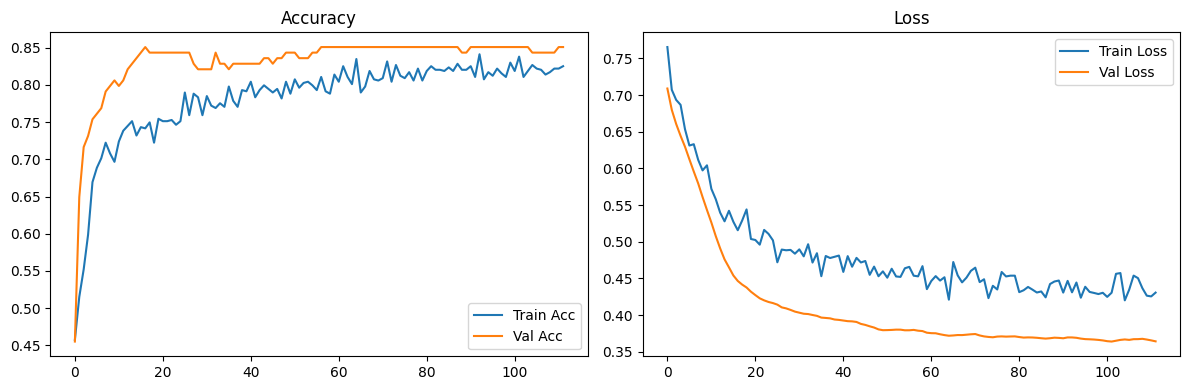

In [14]:
plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.title('Accuracy')
plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Loss')
plt.legend()

plt.tight_layout()
plt.show()

# 7. Evaluate on Test set

In [15]:
y_pred_prob = model.predict(X_test, verbose=0).flatten()
y_pred = (y_pred_prob >= 0.5).astype(int)

acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("\nTest Performance:")
print(f"Accuracy : {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall   : {rec:.4f}")
print(f"F1-score : {f1:.4f}")




Test Performance:
Accuracy : 0.7985
Precision: 0.8333
Recall   : 0.5882
F1-score : 0.6897


# Confusion Matrix

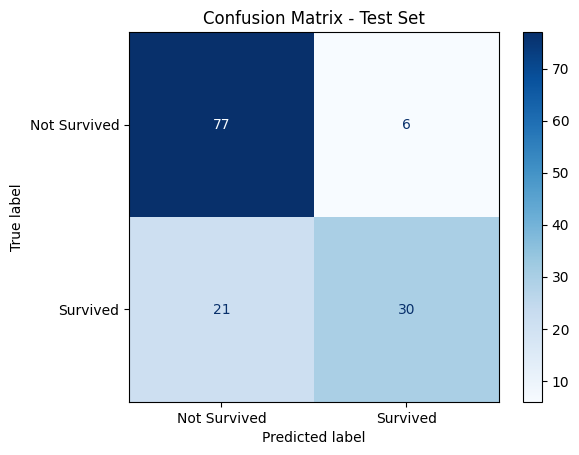

In [16]:
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Not Survived', 'Survived'])
disp.plot(cmap='Blues')
plt.title("Confusion Matrix - Test Set")
plt.show()

# ROC Curve

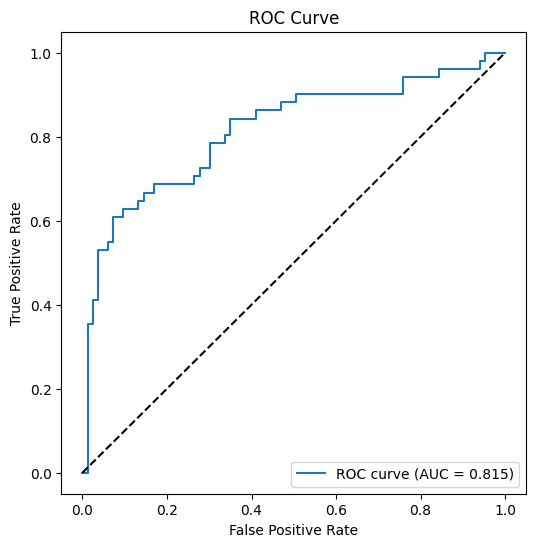

In [17]:
fpr, tpr, _ = roc_curve(y_test, y_pred_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,6))
plt.plot(fpr, tpr, label=f'ROC curve (AUC = {roc_auc:.3f})')
plt.plot([0,1], [0,1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc='lower right')
plt.show()

# 8. Quick prediction example (optional)

# Example: female, Pclass=1, Age=30, no siblings/spouses/parents/children, high fare, embarked C

In [22]:
example = np.array([[1, 30, 0, 0, 100, 1, 0]])  # Sex=1(female), Pclass=1 → wait, wait Pclass is missing here

# Correct order: Pclass, Sex, Age, SibSp, Parch, Fare, Emb_Q, Emb_S

In [20]:
example = np.array([[1, 1, 30, 0, 0, 100, 0, 0]], dtype=np.float32)  # Pclass=1, Sex=female, Emb=C (0,0)
example_scaled = scaler.transform(example)

prob = model.predict(example_scaled, verbose=0)[0][0]
print(f"\nExample passenger survival probability: {prob:.4f}")
print("Prediction:", "Survived" if prob >= 0.5 else "Did not survive")


Example passenger survival probability: 0.9825
Prediction: Survived
